# Diabetes Patient Readmission Analysis
**Dataset:** UCI Diabetes 130-US Hospitals (1999–2008)  
**Author:** Mid-Project Submission

---

## Project Key Questions

1. **What is the overall distribution of hospital readmissions in the dataset?**  
   Goal: To check for class balance and understand the baseline frequency of readmission cases.

2. **Does the average time spent in the hospital increase with the patient's age?**  
   Goal: To investigate the relationship between age groups and hospital resource utilization.

3. **Which medical diagnosis categories have the highest rates of patient readmission?**  
   Goal: To identify high-risk clinical areas that require better post-discharge care.

4. **How do the number of lab procedures and medication counts relate to readmission likelihood?**  
   Goal: To explore whether medical complexity predicts readmission.

5. **What are the most influential features correlated with readmission status?**  
   Goal: To identify the strongest predictors using a correlation matrix.

6. **Does changing a patient's medication dosage affect their readmission probability?**  
   Goal: To analyze if medication stability is a key factor in patient outcomes.

---
## Step 1: Import Libraries & Load Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent visual style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

In [6]:
# Load the dataset — '?' values are treated as missing from the start
df = pd.read_csv('Diabetes_Analysis\diabetic_data.csv', na_values='?')

# Display the first 5 rows to understand the structure
print(f"Dataset shape: {df.shape}")
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\DELL\AppData\Local\Temp\ipykernel_3436\3209742117.py:2: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('Diabetes_Analysis\diabetic_data.csv', na_values='?')


Dataset shape: (101766, 50)


C:\Users\DELL\AppData\Local\Temp\ipykernel_3436\3209742117.py:2: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Diabetes_Analysis\diabetic_data.csv', na_values='?')


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
# Show column data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [8]:
# Display basic descriptive statistics for numerical columns
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


---
## Step 2: Data Cleaning

**Changes documented:**
- Drop high-null columns (`weight`, `payer_code`, `medical_specialty`)
- Fill categorical nulls (`max_glu_serum`, `A1Cresult`) with `'None'`
- Drop rows with few missing values (`race`, `diag_1/2/3`)
- Remove invalid gender entries
- Remove duplicate patient records
- Convert age ranges to numeric midpoints
- Engineer binary flags for visit history

In [9]:
# ── Helper function: summarize missing values ──────────────────────────────
def missing_summary(dataframe):
    """Returns a DataFrame showing missing value counts and percentages."""
    missing = dataframe.isnull().sum()
    missing = missing[missing > 0]
    pct = (missing / len(dataframe) * 100).round(2)
    return pd.DataFrame({'Missing Count': missing, 'Missing %': pct}).sort_values('Missing %', ascending=False)

print("Missing values BEFORE cleaning:")
missing_summary(df)

Missing values BEFORE cleaning:


,Missing Count,Missing %
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


In [10]:
# ── Step 2.1: Drop columns with excessive missing values ───────────────────
# 'weight' is missing in ~97% of rows, 'payer_code' ~40%, 'medical_specialty' ~49%
cols_to_drop = ['weight', 'payer_code', 'medical_specialty']
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped columns: {cols_to_drop}")

Dropped columns: ['weight', 'payer_code', 'medical_specialty']


In [11]:
# ── Step 2.2: Fill missing values in glucose/A1C columns with 'None' ───────
# These columns represent lab tests — a missing value means the test was not done
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult']     = df['A1Cresult'].fillna('None')
print("Filled max_glu_serum and A1Cresult nulls with 'None'.")

Filled max_glu_serum and A1Cresult nulls with 'None'.


In [12]:
# ── Step 2.3: Drop rows with few remaining missing values ──────────────────
before = len(df)
df.dropna(subset=['diag_1', 'diag_2', 'diag_3', 'race'], inplace=True)
print(f"Dropped {before - len(df)} rows with missing diag/race values.")

Dropped 3713 rows with missing diag/race values.


In [13]:
# ── Step 2.4: Remove invalid gender entries ────────────────────────────────
before = len(df)
df = df[df['gender'] != 'Unknown/Invalid']
print(f"Removed {before - len(df)} rows with Unknown/Invalid gender.")

Removed 1 rows with Unknown/Invalid gender.


In [14]:
# ── Step 2.5: Remove duplicate patient records (keep first visit only) ─────
before = len(df)
df.drop_duplicates(subset=['patient_nbr'], keep='first', inplace=True)
print(f"Removed {before - len(df)} duplicate patient records.")

Removed 29423 duplicate patient records.


In [15]:
# ── Step 2.6: Convert age range strings to numeric midpoint values ─────────
# Example: '[70-80)' becomes 75 for easier numerical analysis
age_map = {
    '[0-10)': 5,  '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_map)
print("Age column converted to numeric midpoints.")
print(df[['age', 'age_numeric']].drop_duplicates().sort_values('age_numeric'))

Age column converted to numeric midpoints.
          age  age_numeric
270    [0-10)            5
1     [10-20)           15
2     [20-30)           25
3     [30-40)           35
4     [40-50)           45
5     [50-60)           55
6     [60-70)           65
7     [70-80)           75
8     [80-90)           85
9    [90-100)           95


In [16]:
# ── Step 2.7: Engineer binary visit-history flags ─────────────────────────
# Most patients have 0 emergency/outpatient/inpatient visits
# Converting to binary (0/1) makes the feature more meaningful
df['had_emergency']  = (df['number_emergency']  > 0).astype(int)
df['had_outpatient'] = (df['number_outpatient'] > 0).astype(int)
df['had_inpatient']  = (df['number_inpatient']  > 0).astype(int)
print("Binary visit flags created: had_emergency, had_outpatient, had_inpatient")

Binary visit flags created: had_emergency, had_outpatient, had_inpatient


In [17]:
# ── Step 2.8: Create binary target variable ────────────────────────────────
# readmitted: 'NO' → 0 (not readmitted), '<30' or '>30' → 1 (readmitted)
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)
print("Target variable distribution:")
print(df['readmitted_binary'].value_counts())

Target variable distribution:
readmitted_binary
0    40879
1    27750
Name: count, dtype: int64


In [18]:
# ── Step 2.9: Map ICD-9 diagnosis codes to clinical categories ─────────────
def map_diagnosis(code):
    """Maps an ICD-9 diagnosis code to a broad clinical category."""
    try:
        c = str(code).strip().upper()
        if c.startswith(('V', 'E')) or c in ('?', 'OTHER', 'NAN'):
            return 'Other'
        val = float(c)
        if 390 <= val <= 459 or val == 785:   return 'Circulatory'
        elif 460 <= val <= 519 or val == 786: return 'Respiratory'
        elif 520 <= val <= 579 or val == 787: return 'Digestive'
        elif 250.0 <= val < 251.0:            return 'Diabetes'
        elif 800 <= val <= 999:               return 'Injury'
        elif 710 <= val <= 739:               return 'Musculoskeletal'
        elif 580 <= val <= 629 or val == 788: return 'Genitourinary'
        elif 140 <= val <= 239:               return 'Neoplasms'
        else:                                 return 'Other'
    except:
        return 'Other'

# Apply mapping to all three diagnosis columns
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(map_diagnosis)

print("Primary diagnosis distribution:")
print(df['diag_1'].value_counts())

Primary diagnosis distribution:
diag_1
Circulatory        21255
Other              11892
Respiratory         9454
Digestive           6337
Diabetes            5188
Injury              4563
Musculoskeletal     3888
Genitourinary       3415
Neoplasms           2637
Name: count, dtype: int64


In [19]:
# ── Final Cleaning Verification ────────────────────────────────────────────
print("=" * 40)
print(f"Final dataset shape: {df.shape}")
print(f"Total missing values remaining: {df.isnull().sum().sum()}")
print("=" * 40)

Final dataset shape: (68629, 52)
Total missing values remaining: 0


---
## Step 3: Exploratory Data Analysis (EDA)

### 3.1 Univariate Analysis
Examining the distribution of each variable independently.

C:\Users\DELL\AppData\Local\Temp\ipykernel_3436\2990920655.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='readmitted_binary', data=df, palette='viridis')


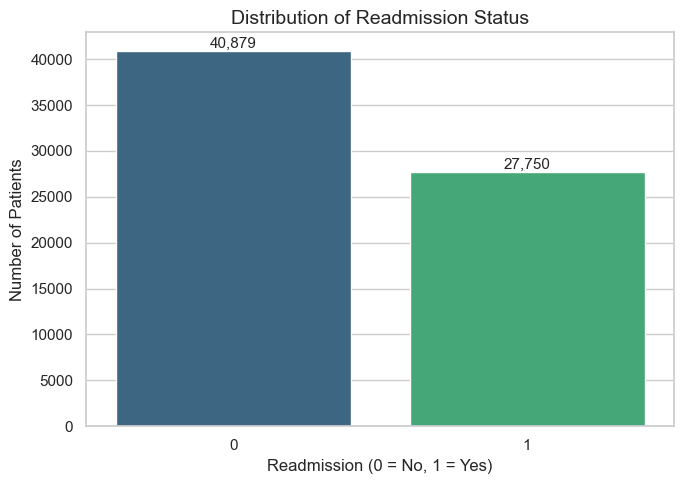

readmitted_binary
0    59.57%
1    40.43%
Name: proportion, dtype: str


In [20]:
# ── Q1: Distribution of Readmission (Target Variable) ─────────────────────
# Countplot to check class balance
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='readmitted_binary', data=df, palette='viridis')
plt.title('Distribution of Readmission Status', fontsize=14)
plt.xlabel('Readmission (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

print(df['readmitted_binary'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

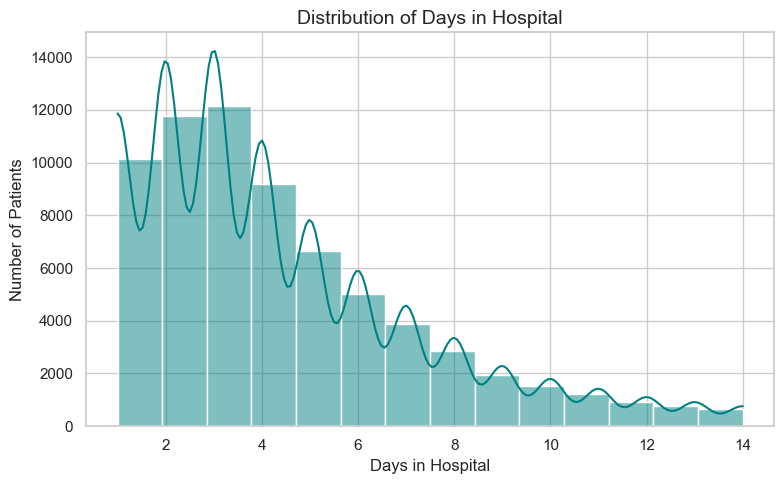

count    68629.000000
mean         4.317184
std          2.957391
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         14.000000
Name: time_in_hospital, dtype: float64


In [21]:
# ── Distribution of Days Spent in Hospital ─────────────────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(df['time_in_hospital'], bins=14, kde=True, color='teal')
plt.title('Distribution of Days in Hospital', fontsize=14)
plt.xlabel('Days in Hospital')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(df['time_in_hospital'].describe())

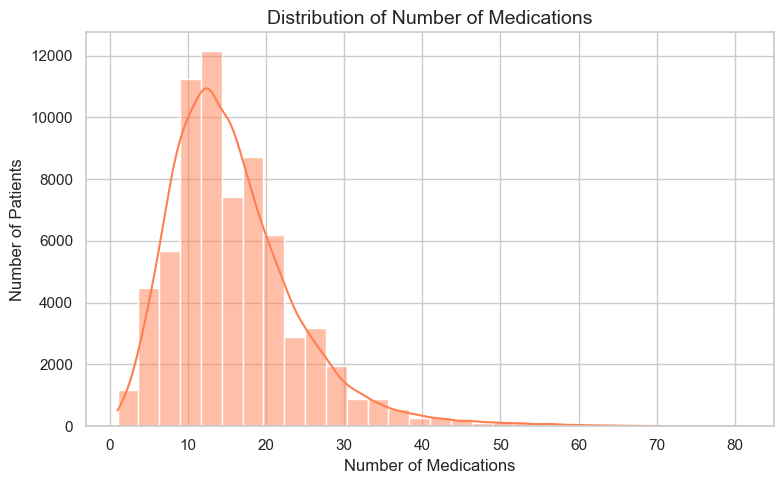

count    68629.000000
mean        15.806481
std          8.289790
min          1.000000
25%         10.000000
50%         14.000000
75%         20.000000
max         81.000000
Name: num_medications, dtype: float64


In [22]:
# ── Distribution of Number of Medications Prescribed ──────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(df['num_medications'], bins=30, kde=True, color='coral')
plt.title('Distribution of Number of Medications', fontsize=14)
plt.xlabel('Number of Medications')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(df['num_medications'].describe())

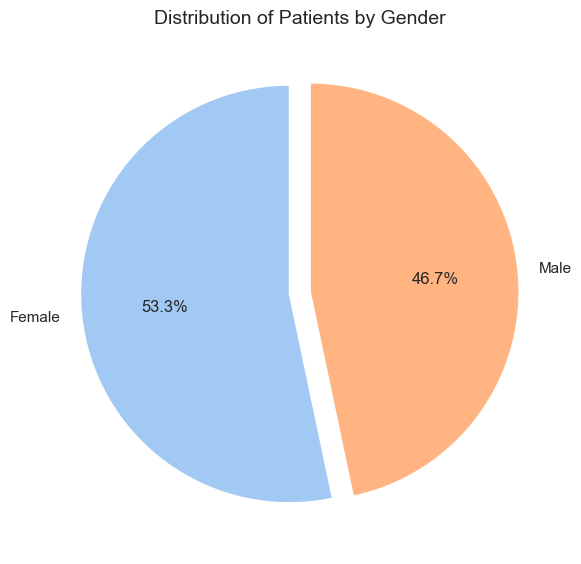

gender
Female    36582
Male      32047
Name: count, dtype: int64


In [23]:
# ── Distribution of Patients by Gender (Pie Chart) ─────────────────────────
plt.figure(figsize=(6, 6))
gender_counts = df['gender'].value_counts()
colors = sns.color_palette('pastel')[0:len(gender_counts)]
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, explode=[0.05]*len(gender_counts))
plt.title('Distribution of Patients by Gender', fontsize=14)
plt.tight_layout()
plt.show()

print(gender_counts)

C:\Users\DELL\AppData\Local\Temp\ipykernel_3436\3246332503.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age', data=df, order=age_order, palette='Blues_d')


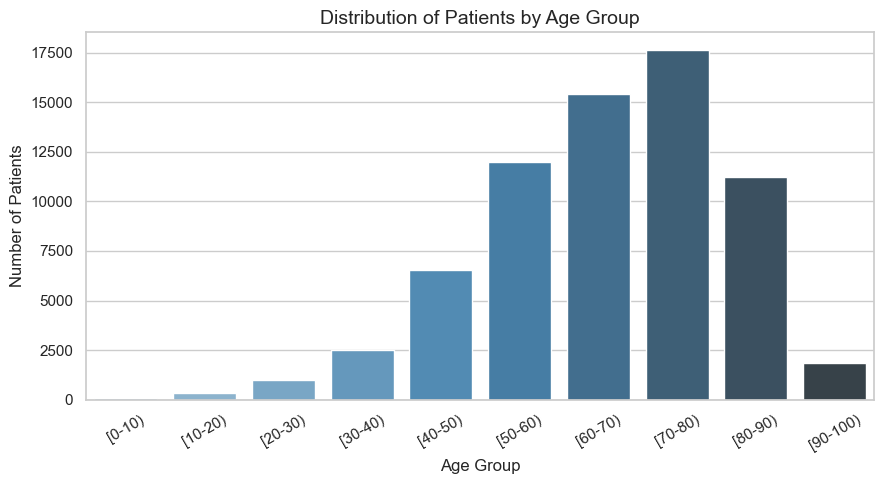

In [24]:
# ── Distribution of Patients by Age Group ─────────────────────────────────
plt.figure(figsize=(9, 5))
age_order = sorted(df['age'].unique())
sns.countplot(x='age', data=df, order=age_order, palette='Blues_d')
plt.title('Distribution of Patients by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

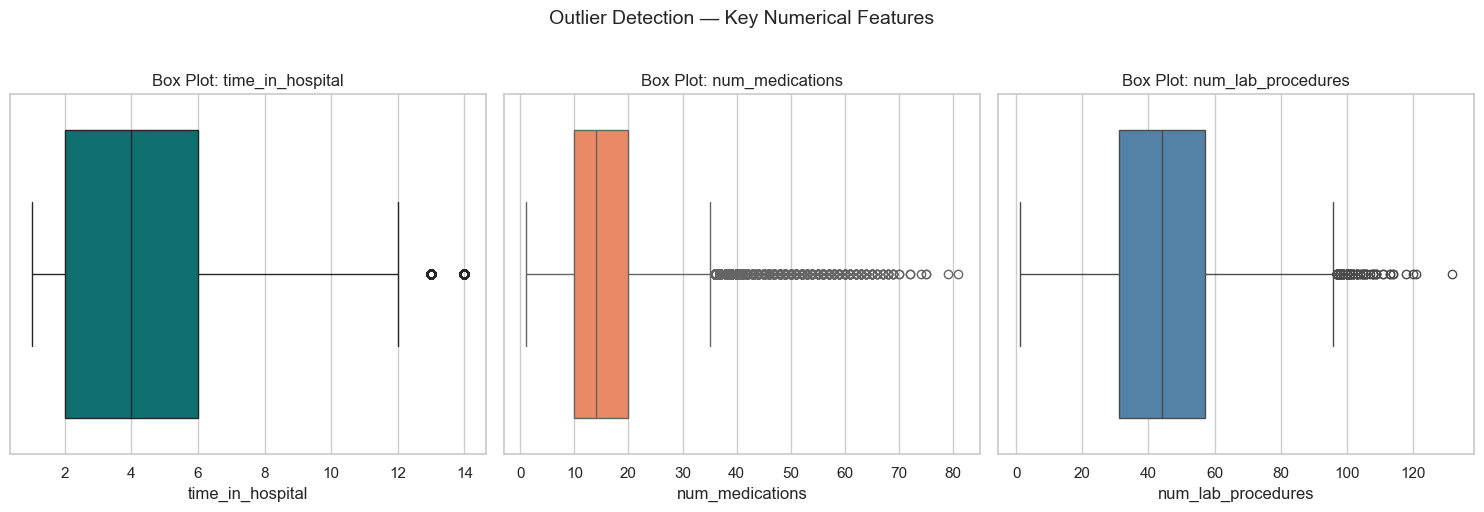

In [25]:
# ── Outlier Detection: Box Plots for Key Numerical Variables ───────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
numerical_vars = ['time_in_hospital', 'num_medications', 'num_lab_procedures']
colors = ['teal', 'coral', 'steelblue']

for ax, col, color in zip(axes, numerical_vars, colors):
    sns.boxplot(x=df[col], ax=ax, color=color)
    ax.set_title(f'Box Plot: {col}', fontsize=12)

plt.suptitle('Outlier Detection — Key Numerical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
### 3.2 Bivariate & Multivariate Analysis
Examining relationships between variables and the target (readmission).

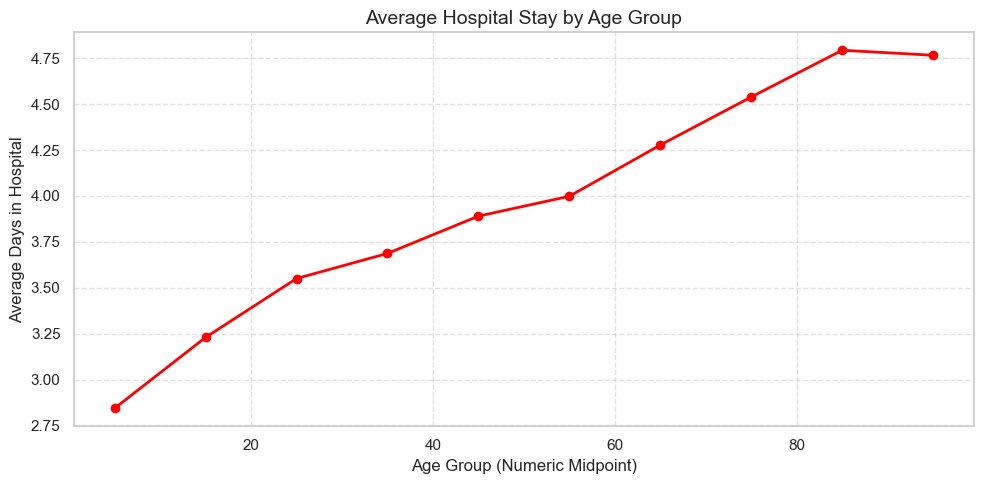

Average hospital stay per age group:
age_numeric
5     2.84
15    3.23
25    3.55
35    3.69
45    3.89
55    4.00
65    4.28
75    4.54
85    4.79
95    4.77
Name: time_in_hospital, dtype: float64


In [26]:
# ── Q2: Does hospital stay increase with age? (Line Plot) ──────────────────
age_trend = df.groupby('age_numeric')['time_in_hospital'].mean()

plt.figure(figsize=(10, 5))
plt.plot(age_trend.index, age_trend.values, marker='o', color='red', linestyle='-', linewidth=2)
plt.title('Average Hospital Stay by Age Group', fontsize=14)
plt.xlabel('Age Group (Numeric Midpoint)')
plt.ylabel('Average Days in Hospital')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Average hospital stay per age group:")
print(age_trend.round(2))

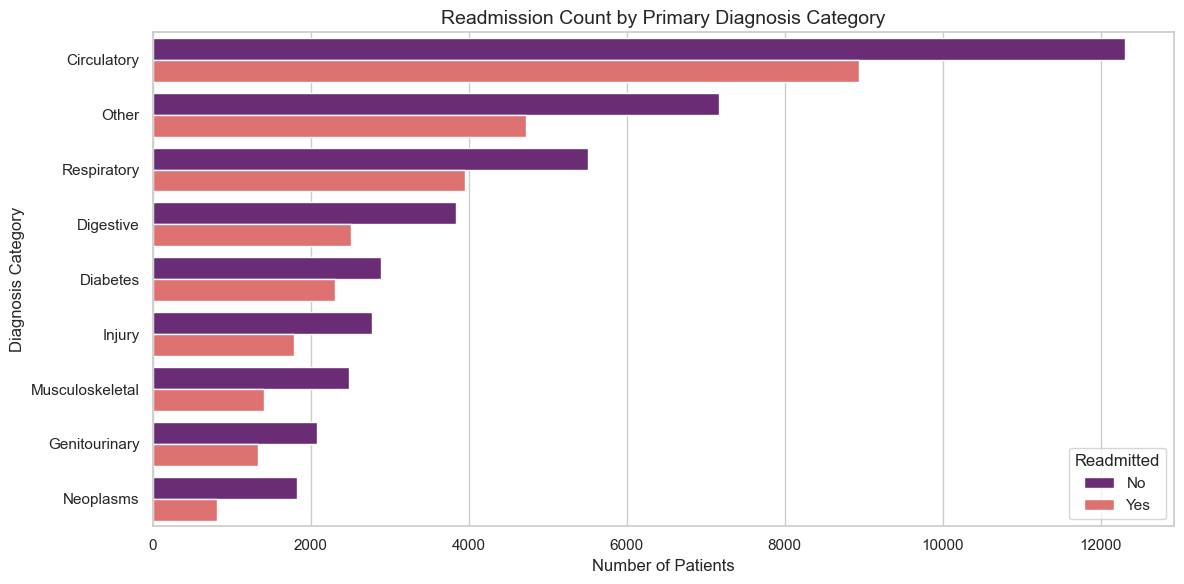

In [27]:
# ── Q3: Which diagnosis has highest readmission rate? (Countplot) ──────────
plt.figure(figsize=(12, 6))
sns.countplot(y='diag_1', hue='readmitted_binary', data=df,
              order=df['diag_1'].value_counts().index, palette='magma')
plt.title('Readmission Count by Primary Diagnosis Category', fontsize=14)
plt.xlabel('Number of Patients')
plt.ylabel('Diagnosis Category')
plt.legend(title='Readmitted', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

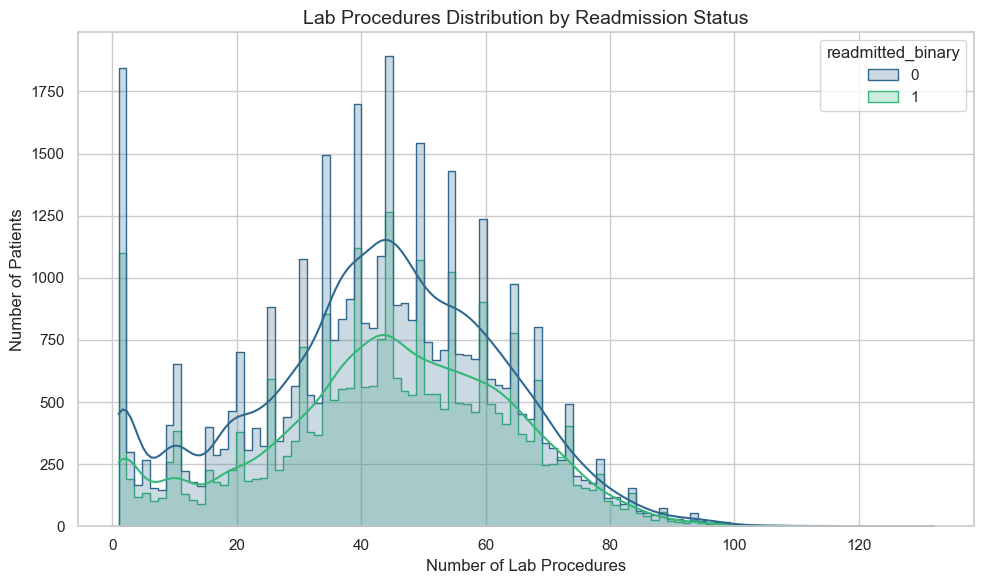

                     count   mean    std  min   25%   50%   75%    max
readmitted_binary                                                     
0                  40879.0  42.41  20.03  1.0  30.0  44.0  56.0  121.0
1                  27750.0  44.19  19.92  1.0  32.0  45.0  58.0  132.0


In [28]:
# ── Q4: Lab procedures vs readmission (Histogram with hue) ────────────────
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='num_lab_procedures', hue='readmitted_binary',
             kde=True, element='step', palette='viridis')
plt.title('Lab Procedures Distribution by Readmission Status', fontsize=14)
plt.xlabel('Number of Lab Procedures')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

# Statistical comparison
print(df.groupby('readmitted_binary')['num_lab_procedures'].describe().round(2))

C:\Users\DELL\AppData\Local\Temp\ipykernel_3436\2608278910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted_binary', y='num_medications', data=df, palette='Set2')


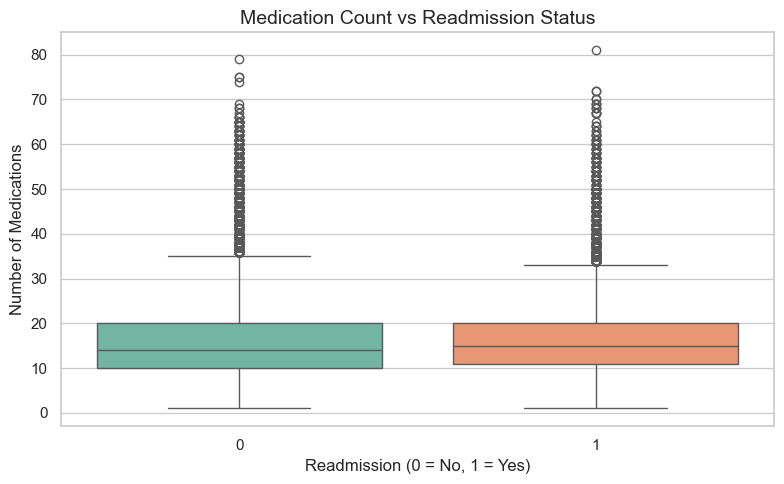

readmitted_binary
0    15.60
1    16.11
Name: num_medications, dtype: float64


In [29]:
# ── Medications vs Readmission (Box Plot) ─────────────────────────────────
plt.figure(figsize=(8, 5))
sns.boxplot(x='readmitted_binary', y='num_medications', data=df, palette='Set2')
plt.title('Medication Count vs Readmission Status', fontsize=14)
plt.xlabel('Readmission (0 = No, 1 = Yes)')
plt.ylabel('Number of Medications')
plt.tight_layout()
plt.show()

print(df.groupby('readmitted_binary')['num_medications'].mean().round(2))

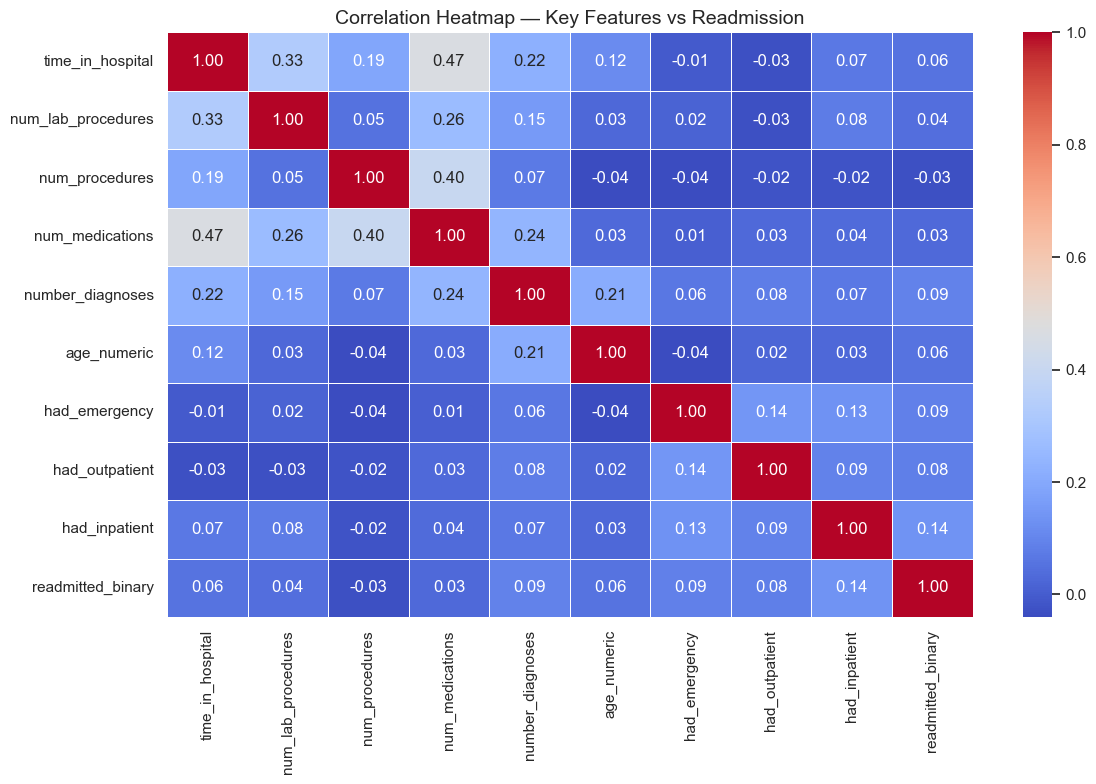

Top correlations with readmission:
readmitted_binary     1.000
had_inpatient         0.137
number_diagnoses      0.092
had_emergency         0.086
had_outpatient        0.082
age_numeric           0.057
time_in_hospital      0.056
num_lab_procedures    0.044
num_medications       0.030
num_procedures       -0.029
Name: readmitted_binary, dtype: float64


In [30]:
# ── Q5: Correlation Heatmap (Top Features vs Readmission) ─────────────────
# Select only numerical columns for correlation analysis
numerical_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                  'num_medications', 'number_diagnoses', 'age_numeric',
                  'had_emergency', 'had_outpatient', 'had_inpatient', 'readmitted_binary']

plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Key Features vs Readmission', fontsize=14)
plt.tight_layout()
plt.show()

print("Top correlations with readmission:")
print(df[numerical_cols].corr()['readmitted_binary'].sort_values(ascending=False).round(3))

C:\Users\DELL\AppData\Local\Temp\ipykernel_3436\4203564189.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Medication Change', y='Readmission Rate', data=change_readmit, palette='coolwarm')


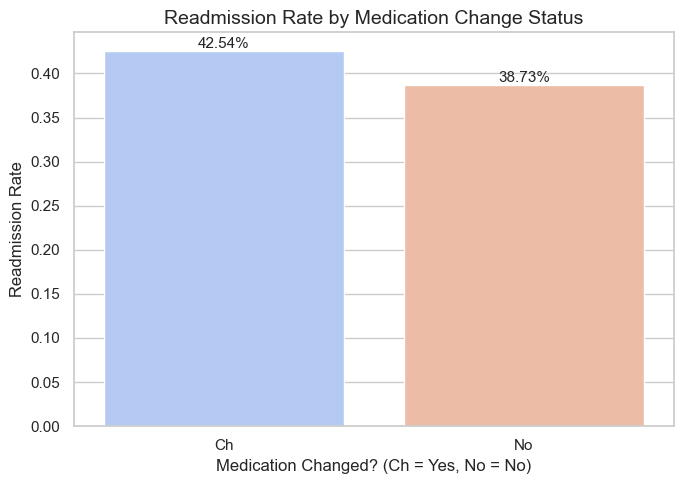

  Medication Change  Readmission Rate
0                Ch          0.425357
1                No          0.387337


In [31]:
# ── Q6: Medication Change vs Readmission Rate (Bar Chart) ─────────────────
change_readmit = df.groupby('change')['readmitted_binary'].mean().reset_index()
change_readmit.columns = ['Medication Change', 'Readmission Rate']

plt.figure(figsize=(7, 5))
ax = sns.barplot(x='Medication Change', y='Readmission Rate', data=change_readmit, palette='coolwarm')
plt.title('Readmission Rate by Medication Change Status', fontsize=14)
plt.xlabel('Medication Changed? (Ch = Yes, No = No)')
plt.ylabel('Readmission Rate')

# Add percentage labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

print(change_readmit)

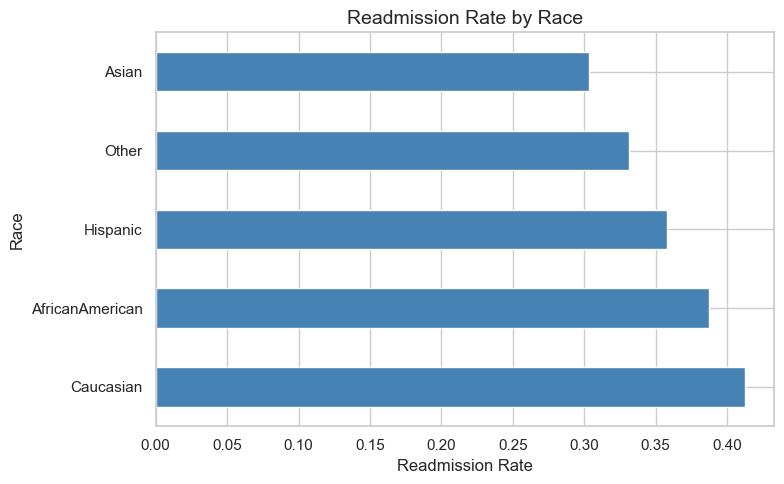

race
Caucasian          0.412
AfricanAmerican    0.388
Hispanic           0.358
Other              0.331
Asian              0.303
Name: readmitted_binary, dtype: float64


In [32]:
# ── Race vs Readmission Rate (Horizontal Bar Chart) ────────────────────────
race_readmit = df.groupby('race')['readmitted_binary'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
race_readmit.plot(kind='barh', color='steelblue')
plt.title('Readmission Rate by Race', fontsize=14)
plt.xlabel('Readmission Rate')
plt.ylabel('Race')
plt.tight_layout()
plt.show()

print(race_readmit.round(3))

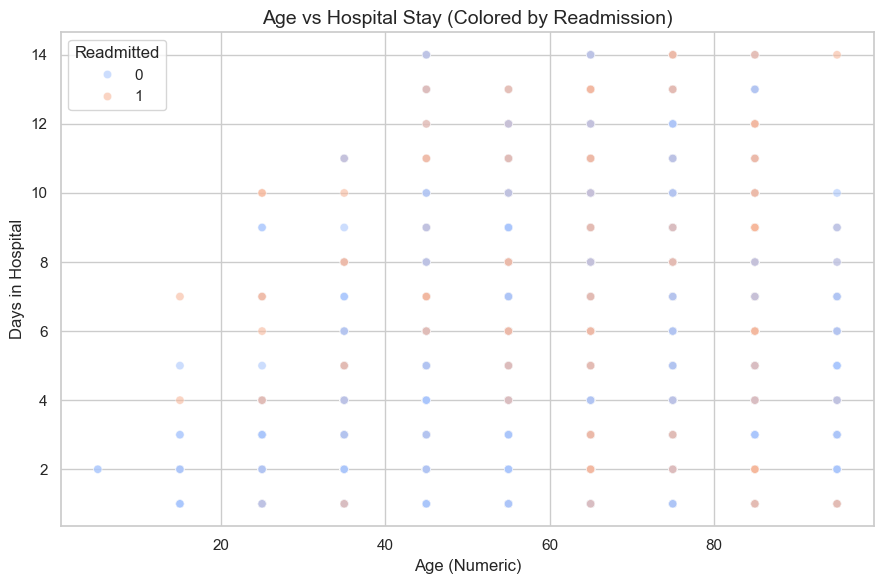

In [33]:
# ── Scatter Plot: Age vs Hospital Stay colored by Readmission ──────────────
plt.figure(figsize=(9, 6))
sns.scatterplot(x='age_numeric', y='time_in_hospital',
                hue='readmitted_binary', data=df.sample(3000, random_state=42),
                palette='coolwarm', alpha=0.6)
plt.title('Age vs Hospital Stay (Colored by Readmission)', fontsize=14)
plt.xlabel('Age (Numeric)')
plt.ylabel('Days in Hospital')
plt.legend(title='Readmitted')
plt.tight_layout()
plt.show()

---
## Step 4: Summary of Findings

| Question | Finding |
|---|---|
| **Q1: Readmission distribution** | Dataset is imbalanced — majority of patients were NOT readmitted |
| **Q2: Age vs Hospital Stay** | Older patients tend to spend more days in the hospital |
| **Q3: Diagnosis & Readmission** | Circulatory and Respiratory conditions show highest readmission counts |
| **Q4: Lab procedures & Meds** | Readmitted patients tend to have more lab procedures and medications |
| **Q5: Feature Correlations** | `had_inpatient` and `num_medications` are the strongest predictors |
| **Q6: Medication Change** | Patients whose medications were changed have a higher readmission rate |